In [7]:
import pandas as pd
import sys
resmat = pd.read_pickle("../data/resmat.pkl")

Bi-factor ability matrix shape: (183, 10)
Number of models: 183
Number of groups: 10


/var/folders/gy/d7p0zrqx7l3f7dwplj0g_b040000gn/T/ipykernel_79672/2944324677.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("./output/mirt_bifactor_gro

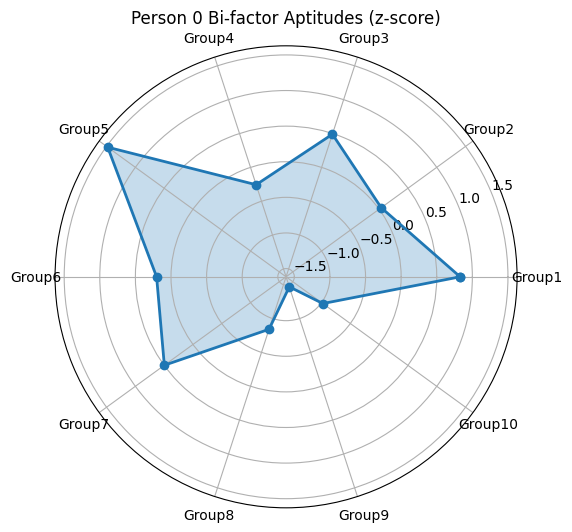

In [8]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import pi

# --- Load model output ---
ckpt = torch.load("./output/mirt_bifactor_groups10.pt", map_location="cpu")
theta_general = ckpt['theta_general'].numpy().squeeze()   # (n_persons,)
theta_group = ckpt['theta_group'].numpy()                 # (n_persons × n_groups)

# --- Combine general and group abilities for each group ---
# For bi-factor models, each group's ability is: general + group_specific
all_abilities = theta_general[:, None] + theta_group  # (n_persons, n_groups)

# --- Create factor scores using model names from resmat ---
factor_names = [f"Group{k+1}" for k in range(theta_group.shape[1])]
ability_df = pd.DataFrame(all_abilities, index=resmat.index, columns=factor_names)

print(f"Bi-factor ability matrix shape: {all_abilities.shape}")
print(f"Number of models: {len(resmat.index)}")
print(f"Number of groups: {theta_group.shape[1]}")

# --- Pick a person (say person 0) for simple demo ---
pid = 0
abilities = theta_general[pid] + theta_group[pid, :]  # combine

# --- Normalize (optional: z-scores across all persons) ---
mean = all_abilities.mean(axis=0)
std = all_abilities.std(axis=0) + 1e-8
abilities_z = (abilities - mean) / std

# --- Simple radar chart for person 0 ---
skills = [f"Group{k+1}" for k in range(theta_group.shape[1])]
angles = np.linspace(0, 2*np.pi, len(skills), endpoint=False).tolist()
abilities_z = np.concatenate([abilities_z, [abilities_z[0]]])  # close loop
angles += [angles[0]]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
ax.plot(angles, abilities_z, 'o-', linewidth=2)
ax.fill(angles, abilities_z, alpha=0.25)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(skills)
ax.set_title(f"Person {pid} Bi-factor Aptitudes (z-score)")
plt.show()


In [22]:
import numpy as np
import pandas as pd

# Suppose you already have a DataFrame of general factor scores
# Example: general_scores = pd.Series(..., index=models, name="General")

general_scores = pd.Series(theta_general, index=resmat.index, name="General")

# ----------------------------
# 1. Check the orientation
# ----------------------------
# Idea: if stronger models (like GPT-4, Claude Opus, Gemini Pro) are negative,
# the mean will be negative. That means the factor needs flipping.
if general_scores.mean() < 0:
    print("⚠️ Flipping general factor orientation...")
    general_scores = -general_scores

# ----------------------------
# 2. Optional: standardize
# ----------------------------
# Make interpretation easier (0 = average, 1 = 1 SD above average)
general_scores = (general_scores - general_scores.mean()) / general_scores.std()

# ----------------------------
# 3. Inspect top and bottom models
# ----------------------------
with pd.option_context('display.max_rows', 10, 'display.max_columns', 10): 
  print("Top models by General factor:")
  print(general_scores.sort_values(ascending=False).head(100))

print("\nBottom models by General factor:")
print(general_scores.sort_values().head(10))


⚠️ Flipping general factor orientation...
Top models by General factor:
request.model
anthropic/claude-3-5-sonnet-20241022    2.311534
anthropic/claude-3-5-sonnet-20240620    2.307611
anthropic/claude-3-opus-20240229        2.036186
openai/gpt-4-turbo-2024-04-09           1.758590
openai/gpt-4o-2024-08-06                1.747980
                                          ...   
google/gemini-1.0-pro-001              -0.021593
ai21/jamba-1.5-mini                    -0.023248
mistralai/mixtral-8x7b-32kseqlen       -0.026356
mosaicml/mpt-instruct-30b              -0.036556
mistralai/open-mistral-nemo-2407       -0.052488
Name: General, Length: 100, dtype: float32

Bottom models by General factor:
request.model
openai/text-babbage-001                    -2.489293
together/glm                               -2.420587
tiiuae/falcon-7b-instruct                  -2.396357
ai21/j1-grande-v2-beta                     -2.370239
openai/text-ada-001                        -2.270777
ai21/j2-grande     

In [29]:
import numpy as np
import pandas as pd

# Ensure general factor is 2D: (n_models, 1)
theta_general_2d = np.atleast_2d(theta_general).T

# Combine into one matrix
all_scores = np.hstack([theta_general_2d, theta_group])

# Build DataFrame
scores = pd.DataFrame(
    all_scores,
    index=resmat.index,  # or model_names
    columns=["General"] + [f"Skill_{i+1}" for i in range(theta_group.shape[1])]
)

# ----------------------------
# 2. Fix orientation of each factor
# ----------------------------
for col in scores.columns:
    if scores[col].mean() < 0:  # flip if mostly negative
        scores[col] = -scores[col]
    # Standardize
    scores[col] = (scores[col] - scores[col].mean()) / scores[col].std()

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(scores['General'].sort_values(ascending=False).head(200))


request.model
anthropic/claude-3-5-sonnet-20241022               2.311534
anthropic/claude-3-5-sonnet-20240620               2.307611
anthropic/claude-3-opus-20240229                   2.036186
openai/gpt-4-turbo-2024-04-09                      1.758590
openai/gpt-4o-2024-08-06                           1.747980
google/gemini-1.5-flash-001-safety-block-none      1.697671
google/gemini-1.5-pro-001-safety-block-none        1.671386
qwen/qwen2.5-72b-instruct-turbo                    1.590872
openai/gpt-4-0613                                  1.581232
openai/o3-mini-2025-01-31                          1.580152
openai/o1-2024-12-17                               1.558260
qwen/qwen2-72b-instruct                            1.456754
google/gemini-1.5-pro-002                          1.448657
openai/gpt-4o-2024-05-13                           1.432104
meta/llama-3.1-405b-instruct-turbo                 1.386488
meta/llama-3.2-90b-vision-instruct-turbo           1.316106
amazon/nova-pro-v1:0      

In [17]:
theta_df = pd.DataFrame(theta_general, index=resmat.index, columns=['General'])
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
  print(theta_df.sort_values(by='General', ascending=False))

                                                  General
request.model                                            
openai/text-babbage-001                          5.914529
together/glm                                     5.731361
tiiuae/falcon-7b-instruct                        5.666766
ai21/j1-grande-v2-beta                           5.597137
openai/text-ada-001                              5.331979
ai21/j2-grande                                   5.131262
tiiuae/falcon-7b                                 4.850399
meta/llama-30b                                   4.750208
ai21/j1-grande                                   4.259282
together/redpajama-incite-instruct-3b-v1         4.199138
ai21/j1-large                                    4.061118
meta/llama-2-7b                                  3.963865
cohere/medium-20221108                           3.582355
eleutherai/pythia-1b-v0                          3.414883
cohere/small-20220720                            3.240359
cohere/command

META models (sorted by average bi-factor score):
request.model
meta/llama-2-7b                             4.478977
meta/llama-3-8b                             0.591907
meta/llama-65b                              0.541050
meta/llama-2-13b                            0.342733
meta/llama-2-70b                           -0.382475
meta/llama-3.2-11b-vision-instruct-turbo   -0.592085
meta/llama-3.1-8b-instruct-turbo           -1.012281
meta/llama-3.1-70b-instruct-turbo          -1.963284
meta/llama-3-70b                           -2.982214
meta/llama-3.3-70b-instruct-turbo          -3.354408
meta/llama-3.2-90b-vision-instruct-turbo   -3.520557
meta/llama-3.1-405b-instruct-turbo         -3.946262
dtype: float32
OPENAI models (sorted by average bi-factor score):
request.model
openai/text-davinci-002          0.601552
openai/text-davinci-003          0.438356
openai/gpt-3.5-turbo-0613       -0.602403
openai/gpt-4o-mini-2024-07-18   -2.573161
openai/gpt-4-1106-preview       -2.792192
openai/gpt-

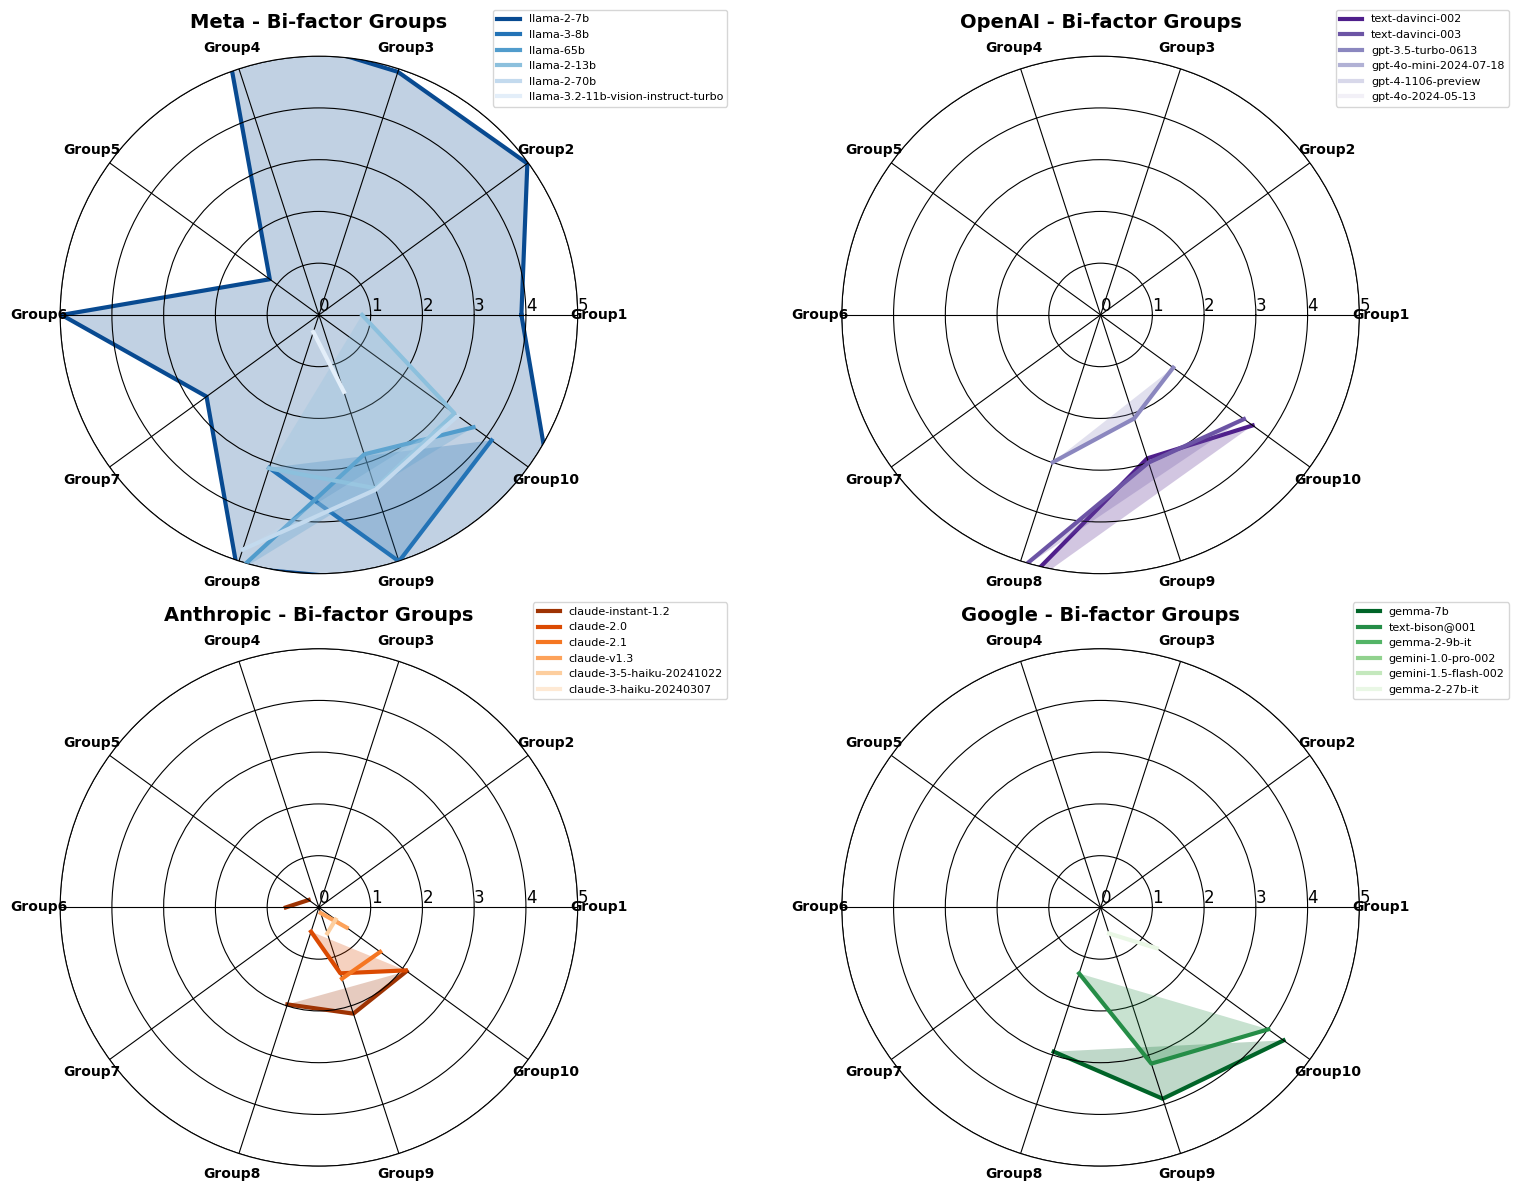

\nSelected models for bi-factor radar charts:
\nMETA:
  meta/llama-2-7b (avg: 4.479)
  meta/llama-3-8b (avg: 0.592)
  meta/llama-65b (avg: 0.541)
  meta/llama-2-13b (avg: 0.343)
  meta/llama-2-70b (avg: -0.382)
  meta/llama-3.2-11b-vision-instruct-turbo (avg: -0.592)
\nOPENAI:
  openai/text-davinci-002 (avg: 0.602)
  openai/text-davinci-003 (avg: 0.438)
  openai/gpt-3.5-turbo-0613 (avg: -0.602)
  openai/gpt-4o-mini-2024-07-18 (avg: -2.573)
  openai/gpt-4-1106-preview (avg: -2.792)
  openai/gpt-4o-2024-05-13 (avg: -3.581)
\nANTHROPIC:
  anthropic/claude-instant-1.2 (avg: 0.072)
  anthropic/claude-2.0 (avg: -0.977)
  anthropic/claude-2.1 (avg: -0.980)
  anthropic/claude-v1.3 (avg: -1.194)
  anthropic/claude-3-5-haiku-20241022 (avg: -1.593)
  anthropic/claude-3-haiku-20240307 (avg: -2.696)
\nGOOGLE:
  google/gemma-7b (avg: 0.645)
  google/text-bison@001 (avg: -0.327)
  google/gemma-2-9b-it (avg: -1.242)
  google/gemini-1.0-pro-002 (avg: -1.590)
  google/gemini-1.5-flash-002 (avg: -2.071)


In [10]:
# --- Multi-Model Radar Charts by Company (adapted from demo-rotational) ---

# Create individual score series for each group (similar to rotational approach)
group_scores = {}
for i in range(all_abilities.shape[1]):
    group_scores[f'Group{i+1}'] = pd.Series(all_abilities[:, i], index=resmat.index)

# Get common indices (models that have non-NaN values for math and gsm scenarios)
common_indices = resmat[resmat.columns[resmat.columns.get_level_values('scenario').isin(['math', 'gsm'])]].dropna().index.to_list()

# Create skill scores DataFrame
skill_scores = pd.DataFrame(group_scores)
skill_scores = skill_scores.loc[common_indices]

# Function to create radar chart
def create_radar_chart(data, labels, title, ax, colors=None, model_names=None):
    """
    Create a radar chart for given data
    """
    # Number of variables
    N = len(labels)
    
    # Compute angle for each axis
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # Complete the circle
    
    # Initialize colors if not provided
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(data)))
    
    # Plot each model
    for i, (model_data, color) in enumerate(zip(data, colors)):
        values = model_data.tolist()
        values += values[:1]  # Complete the circle
        
        model_name = model_names[i] if model_names else f'Model {i+1}'
        # Extract just the model name after the company prefix
        display_name = model_name.split('/')[-1] if '/' in model_name else model_name
        
        ax.plot(angles, values, '-', linewidth=3, label=display_name, color=color, alpha=1, zorder=i + 1)
        ax.fill(angles, values, color=color, alpha=0.25, zorder=i + 1)
    
    # Add labels
    ax.tick_params(pad=5)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10, weight='bold')
    ax.set_ylim(-3, 5)  # Set consistent scale
    ax.set_title(title, size=14, weight='bold', pad=20)
    ax.grid(True, alpha=1, color='black', zorder=10)
    
    # Ensure y-ticks align with circles
    ax.set_rgrids([-3, -2, -1, 0, 1, 2, 3, 4, 5], angle=0, labels=["-3", "-2", "-1", "0", "1", "2", "3", "4", "5"], fontsize=12)

    # Hide the zero label
    ax.set_rmin(0)

# Filter and group models by company
companies = {
    'meta': [],
    'openai': [], 
    'anthropic': [],
    'google': []
}

# Group models by company prefix (only include models that have all group scores)
common_models = skill_scores.dropna().index
for model in common_models:
    if model.startswith('meta/'):
        companies['meta'].append(model)
    elif model.startswith('openai/'):
        companies['openai'].append(model)
    elif model.startswith('anthropic/'):
        companies['anthropic'].append(model)
    elif model.startswith(('google/')):
        companies['google'].append(model)

# Select top models from each company with explicit model inclusion
def select_top_models(models, n=6, explicit_models=None):
    """
    Select top models from a list, with option to include explicit models.
    
    Args:
        models: List of model names to choose from
        n: Number of top models to select
        explicit_models: List of model names that must be included if they exist in models
        
    Returns:
        List of selected model names
    """
    if not models:
        return []
    
    # Initialize result with explicit models that exist in the models list
    result = []
    if explicit_models:
        result = [model for model in explicit_models if model in models]
    
    # If we already have enough models from explicit list, return them
    if len(result) >= n:
        return result[:n]
    
    # Get model scores and sort by performance
    model_scores = skill_scores.loc[models].mean(axis=1).sort_values(ascending=False)
    print(f"{models[0].split('/')[0].upper()} models (sorted by average bi-factor score):")
    print(model_scores)
    
    # Add top performing models that aren't already in the result
    remaining_slots = n - len(result)
    for model in model_scores.index:
        if model not in result:
            result.append(model)
            remaining_slots -= 1
            if remaining_slots == 0:
                break
    
    return result

# Define explicit models to include for each company
explicit_models_by_company = {
    'openai': ['openai/text-davinci-002'],
    # Add other companies and their explicit models as needed
}

# Get top models for each company with explicit model inclusion
selected_models = {
    company: select_top_models(
        models, 
        n=6, 
        explicit_models=explicit_models_by_company.get(company, [])
    ) 
    for company, models in companies.items()
}

# Create the radar charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

# Skill labels (bi-factor groups)
skill_labels = list(group_scores.keys())

company_names = ['Meta', 'OpenAI', 'Anthropic', 'Google']
company_keys = ['meta', 'openai', 'anthropic', 'google']

for i, (company_key, company_name) in enumerate(zip(company_keys, company_names)):
    models = selected_models[company_key]
    if models:
        # Get data for selected models using skill scores
        model_data = skill_scores.loc[models].values
        
        # Create color palette for this company
        if company_key == 'meta':
            colors = plt.cm.Blues_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'openai':
            colors = plt.cm.Purples_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'anthropic':
            colors = plt.cm.Oranges_r(np.linspace(0.1, 0.9, len(models)))
        elif company_key == 'google':
            colors = plt.cm.Greens_r(np.linspace(0.1, 0.9, len(models)))
            
        create_radar_chart(model_data, skill_labels, f'{company_name} - Bi-factor Groups', axes[i], 
                         colors=colors, model_names=models)
        
        # Add legend with abbreviated names
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
    else:
        axes[i].text(0.5, 0.5, f'No {company_name} models found', 
                    transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(f'{company_name} - Bi-factor Groups', size=14, weight='bold', pad=20)

plt.tight_layout()
plt.savefig('../result/bifactor_model_families_radar_charts.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Print summary of selected models and their scores
print("\\nSelected models for bi-factor radar charts:")
for company, models in selected_models.items():
    print(f"\\n{company.upper()}:")
    for model in models:
        scores = skill_scores.loc[model]
        avg_score = scores.mean()
        print(f"  {model} (avg: {avg_score:.3f})")

print(f"\\nBi-factor model summary:")
print(f"Total groups: {len(skill_labels)}")
print(f"Models analyzed: {len(common_models)}")
print(f"Companies: {[k for k, v in companies.items() if v]}")
